# OU+Threshold: the paper's parametric baseline

Guijarro-Ordonez, Pelger, Zanotti, *Deep Learning Statistical Arbitrage*: Section II.D.1, Appendix B.B, the "OU+Thresh" row of Table I.

This notebook walks through the classical mean-reversion strategy on residuals: **residual → OU signal → position → PnL**. First on a single asset, then on a portfolio of ~870 residuals, on the official OOS residuals of the paper's authors (CRSP, 1998-2016).

The full experiment suite (all K, threshold grid, Avellaneda-Lee, by-year breakdown, synthetic study) is in `docs/OU_BASELINE.md`, scripts `scripts/ou_experiments.py` and `scripts/ou_synthetic.py`.

Needs the official repository cloned into `references/dlsa-public` (see README).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from dlsa_baseline.data.official_residuals import load_official_residuals
from dlsa_baseline.models.ou import ou_signal, threshold_positions
from dlsa_baseline.training.ou_backtest import OURule, annualized, backtest_ou

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
L, OOS_START = 30, "2002-01-01"
ipca = load_official_residuals("IPCA", 5)
R, dates = ipca.residuals.astype(np.float64), ipca.dates
print(R.shape, dates[0], dates[-1], f"zeros (asset outside universe): {np.mean(R == 0):.0%}")

(4781, 9483) 1998-01-02 2016-12-30 zeros (asset outside universe): 91%


## 1. Model

The cumulative residual over the last $L=30$ days, $X_l=\sum_{j\le l}\epsilon_{t-L+j}$, is the "price" of the arbitrage portfolio. We treat it as a discretely observed Ornstein-Uhlenbeck process:

$$dX_t=\kappa(\mu-X_t)\,dt+\sigma\,dB_t \quad\Longrightarrow\quad X_{l+1}=a+bX_l+e_l \;\;(\text{AR}(1),\ \Delta t=1\text{ day}).$$

| Parameter | Estimate | Meaning |
|---|---|---|
| $\kappa$ | $-\ln \hat b$ | reversion speed; half-life $\ln 2/\kappa$ days |
| $\mu$ | $\hat a/(1-\hat b)$ | equilibrium level (the residual's "fair price") |
| $\sigma/\sqrt{2\kappa}$ | $\sqrt{\hat\sigma_e^2/(1-\hat b^2)}$ | typical deviation from $\mu$ at equilibrium |
| $R^2$ | correlation$(X_l, X_{l+1})^2$ | how well AR(1) fits this window at all |

The signal is $\theta^{OU}=(\kappa,\mu,\sigma/\sqrt{2\kappa},X_L,R^2)$. The Avellaneda-Lee (2010) / Yeo-Papanicolaou (2017) rule acts on the s-score $s=(X_L-\mu)/(\sigma/\sqrt{2\kappa})$:

$$w=\begin{cases}-1 & s>c_{thresh},\ R^2>c_{crit} \quad\text{(residual is "rich": sell)}\\ +1 & s<-c_{thresh},\ R^2>c_{crit}\quad\text{(residual is "cheap": buy)}\\ 0 & \text{otherwise}\end{cases}\qquad c_{thresh}=1.25,\ c_{crit}=0.25.$$

The model is only valid for $0<\hat b<1$ (mean reversion present). The position is decided from window $[t-30, t-1]$ and earns the residual return on day $t$.

## 2. One window: what the model estimates

asset_81, window ending 2002-05-20
b = 0.742  kappa = 0.299/day  half-life = 2.3 days
mu = +0.0414  X_L = +0.0786  sigma_eq = 0.0192  R^2 = 0.44
s = +1.94  ->  position -1


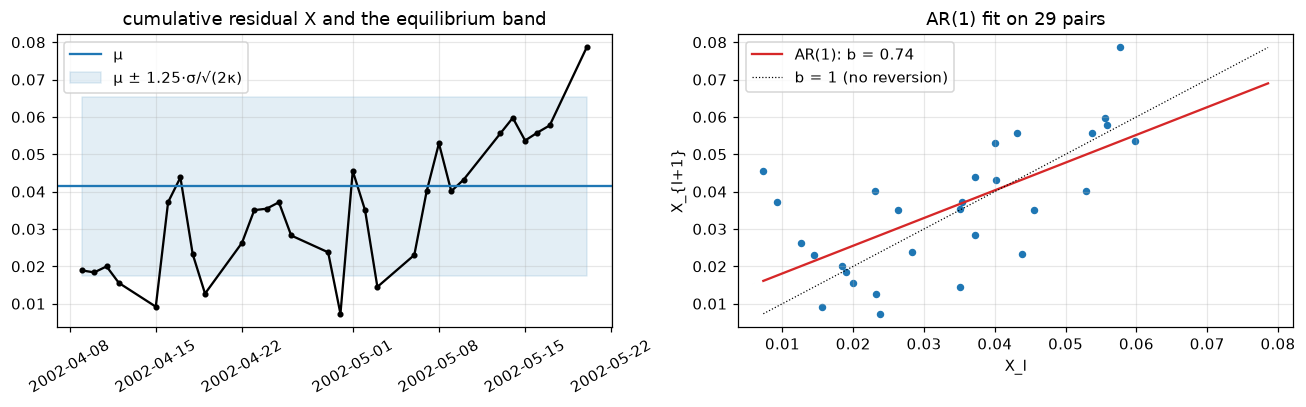

In [2]:
def fit_window(asset, t):
    """OU fit on residuals [t-L, t-1] of one asset."""
    window = R[t - L : t, [asset]]
    signal = ou_signal(window)
    b = float(np.exp(-signal.kappa[0]))
    return window[:, 0], signal, b

asset, t = 81, int(np.searchsorted(dates, np.datetime64("2002-05-21")))
window, sig, b = fit_window(asset, t)
X = np.cumsum(window)
print(f"asset_{asset}, window ending {dates[t - 1]}")
print(f"b = {b:.3f}  kappa = {sig.kappa[0]:.3f}/day  half-life = {np.log(2) / sig.kappa[0]:.1f} days")
print(f"mu = {sig.mu[0]:+.4f}  X_L = {sig.last[0]:+.4f}  sigma_eq = {sig.sigma_eq[0]:.4f}  R^2 = {sig.r2[0]:.2f}")
print(f"s = {sig.s_score[0]:+.2f}  ->  position {threshold_positions(sig)[0]:+.0f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
ax[0].plot(dates[t - L : t], X, "k.-")
ax[0].axhline(sig.mu[0], color="C0", label="μ")
ax[0].fill_between(dates[t - L : t], sig.mu[0] - 1.25 * sig.sigma_eq[0], sig.mu[0] + 1.25 * sig.sigma_eq[0],
                   color="C0", alpha=0.12, label="μ ± 1.25·σ/√(2κ)")
ax[0].set_title("cumulative residual X and the equilibrium band"); ax[0].legend(); ax[0].tick_params(axis="x", rotation=30)
ax[1].scatter(X[:-1], X[1:], s=15)
grid = np.linspace(X.min(), X.max(), 10)
a = sig.mu[0] * (1 - b)
ax[1].plot(grid, a + b * grid, "C3", label=f"AR(1): b = {b:.2f}")
ax[1].plot(grid, grid, "k:", lw=0.8, label="b = 1 (no reversion)")
ax[1].set(xlabel="X_l", ylabel="X_{l+1}", title="AR(1) fit on 29 pairs"); ax[1].legend()
plt.tight_layout()

## 3. Residual → s-score → position → PnL on a single asset

Trade one residual with $w\in\{-1,0,1\}$ (as in the paper's Fig. A.2) over the 30 days following the window. The first example is a **trend, where OU fails**; the second is oscillation, where it works. Both were found with `scripts/ou_experiments.py example`; the second is hand-picked as a favorable case, not a typical one.

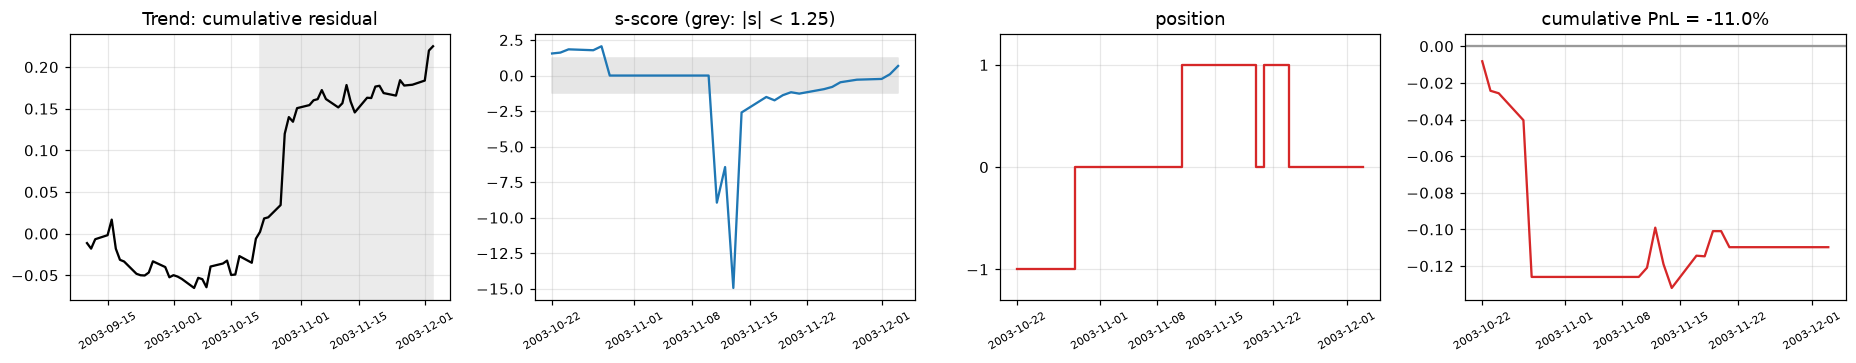

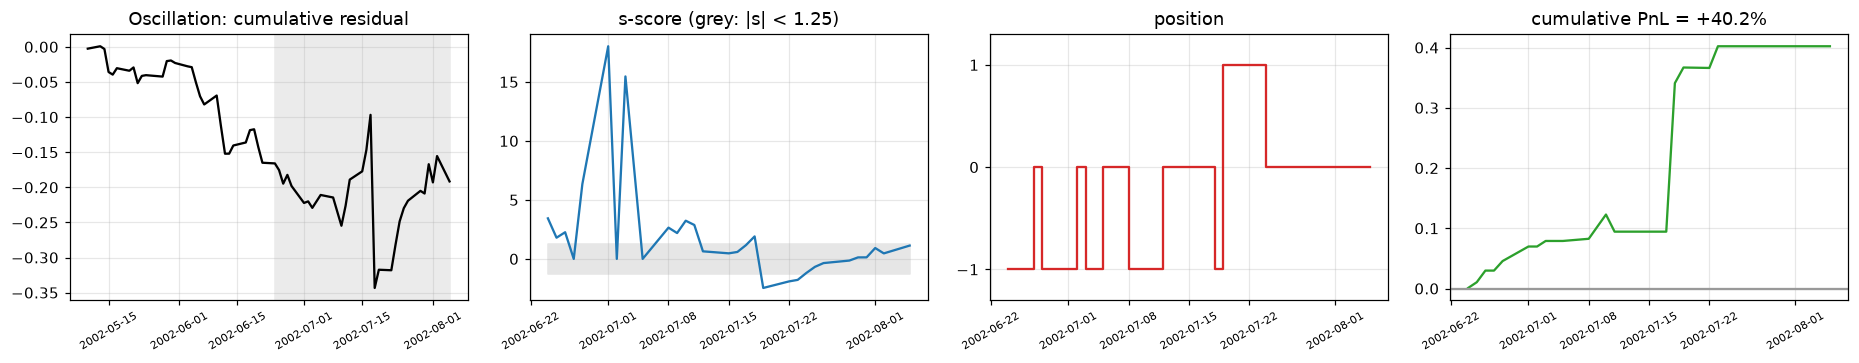

In [3]:
def single_asset(asset, start, horizon=30):
    t0 = int(np.searchsorted(dates, np.datetime64(start)))
    s, w = np.zeros(horizon), np.zeros(horizon)
    for h in range(horizon):
        sig = ou_signal(R[t0 + h - L : t0 + h, [asset]])
        s[h], w[h] = sig.s_score[0], threshold_positions(sig)[0]
    return t0, s, w, w * R[t0 : t0 + horizon, asset]

def four_panels(asset, start, title):
    t0, s, w, pnl = single_asset(asset, start)
    oos, span = dates[t0 : t0 + 30], dates[t0 - L : t0 + 30]
    fig, ax = plt.subplots(1, 4, figsize=(17, 3.4))
    ax[0].plot(span, np.cumsum(R[t0 - L : t0 + 30, asset]), "k"); ax[0].axvspan(oos[0], oos[-1], color="0.92")
    ax[0].set_title(f"{title}: cumulative residual")
    ax[1].plot(oos, s); ax[1].fill_between(oos, -1.25, 1.25, color="0.9"); ax[1].set_title("s-score (grey: |s| < 1.25)")
    ax[2].step(oos, w, where="post", color="C3"); ax[2].set(ylim=(-1.3, 1.3), yticks=[-1, 0, 1], title="position")
    ax[3].plot(oos, np.cumsum(pnl), color="C2" if pnl.sum() > 0 else "C3"); ax[3].axhline(0, color="0.6")
    ax[3].set_title(f"cumulative PnL = {pnl.sum():+.1%}")
    for a in ax: a.tick_params(axis="x", rotation=30, labelsize=7)
    plt.tight_layout()

four_panels(6218, "2003-10-22", "Trend")
four_panels(1726, "2002-06-24", "Oscillation")

**Why OU fails on a trend.** The rule bets against the last move: as the price rises, the s-score climbs and the rule shorts. If the move has momentum, every such bet loses, and by the time the uptrend ends the rule has flipped to long near the top. A single speed $\kappa$ and a single equilibrium $\mu$ cannot describe a trend or a mix of frequencies; this is exactly why the paper replaces this signal with a CNN+Transformer.

## 4. Portfolio: all residuals, 2002-2016, against Table I

In [4]:
PAPER = {"FF": 0.38, "PCA": 0.73, "IPCA": 0.97}
results, rows = {}, []
for family in ("FF", "PCA", "IPCA"):
    data = ipca if family == "IPCA" else load_official_residuals(family, 5)
    bt = backtest_ou(data, OURule(), start=OOS_START)
    results[family] = bt
    gross, net = annualized(bt.returns), annualized(bt.net_returns())
    rows.append({"family": family, "SR": gross["SR"], "paper SR": PAPER[family], "μ": gross["mu"], "σ": gross["sigma"],
                 "SR net of costs": net["SR"], "turnover/day": bt.turnover.mean(),
                 "positions/day": (bt.n_long + bt.n_short).mean(), "universe/day": bt.n_universe.mean()})
formats = {"SR": "{:.2f}", "paper SR": "{:.2f}", "μ": "{:.1%}", "σ": "{:.1%}", "SR net of costs": "{:.2f}",
           "turnover/day": "{:.2f}", "positions/day": "{:.0f}", "universe/day": "{:.0f}"}
pd.DataFrame(rows).set_index("family").style.format(formats)

,SR,paper SR,μ,σ,SR net of costs,turnover/day,positions/day,universe/day
family,,,,,,,,
FF,0.34,0.38,1.2%,3.6%,-3.40,0.96,156,869
PCA,0.93,0.73,2.4%,2.6%,-4.16,0.96,156,869
IPCA,0.64,0.97,2.6%,4.1%,-2.68,0.97,154,869


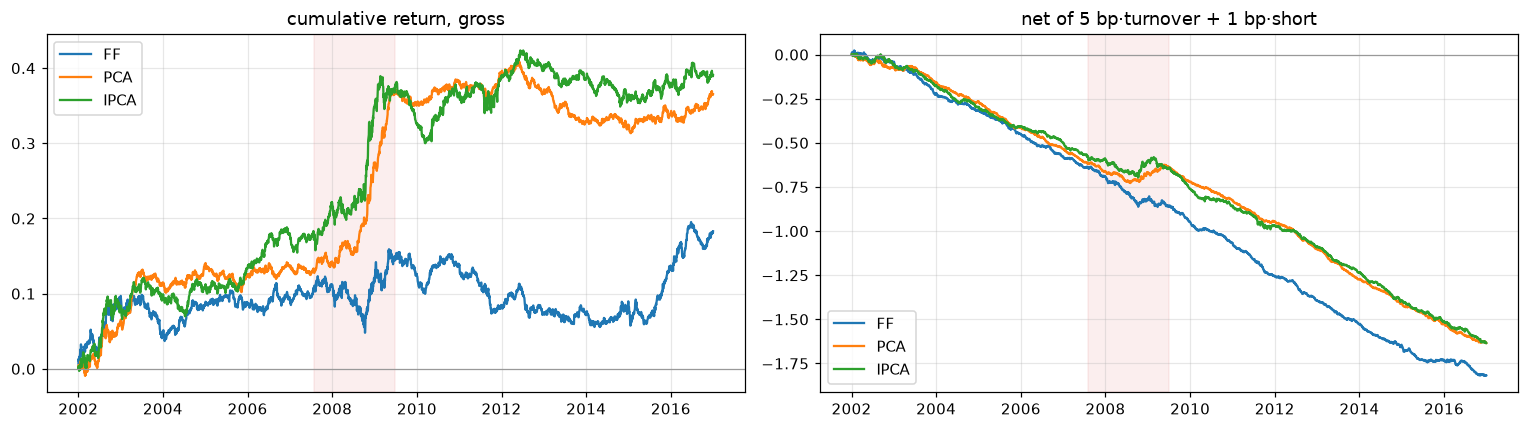

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4), sharex=True)
for family, bt in results.items():
    ax[0].plot(bt.dates, np.cumsum(bt.returns), label=family)
    ax[1].plot(bt.dates, np.cumsum(bt.net_returns()), label=family)
ax[0].set_title("cumulative return, gross"); ax[1].set_title("net of 5 bp·turnover + 1 bp·short")
for a in ax: a.axhline(0, color="0.6", lw=0.8); a.axvspan(np.datetime64("2007-08-01"), np.datetime64("2009-06-30"), color="C3", alpha=0.08); a.legend()
plt.tight_layout()

## 5. Talking points for the defense

1. **The order of magnitude replicates.** SR 0.34 / 0.93 / 0.64 vs 0.38 / 0.73 / 0.97. Exact numbers will not match: the paper maps residual weights to stock weights through `Phi`, which is not published. The K=0 check (`Phi = I`) matches the paper: -0.23 vs -0.18.
2. **`Phi` only rescales the day's leverage.** Since $\epsilon_t=\Phi_{t-1}R_t$, the paper's PnL is $w'\epsilon_t/\|\Phi'w\|_1$, ours is $w'\epsilon_t/\|w\|_1$: the sign of every day's PnL is the same.
3. **PCA > IPCA here comes from 2008-2009** (57% of PCA's PnL). Excluding the crisis restores the paper's ranking: IPCA 0.60 > PCA 0.51 > FF 0.40.
4. **OU does not survive costs**: turnover is ~1 per day, break-even is at most ~2 bp. The Avellaneda-Lee hysteresis rule halves turnover but does not rescue it.
5. **Tuning the thresholds does not save OU**: the best grid cell is 1.28 vs 3.2-4.2 for CNN+Transformer; the R² filter in effect selects slow, trend-like windows ($R^2\approx \hat b^2$).
6. **Independent cross-check**: `experiments/models.py:OUThreshold` (Timur's harness) gives the same positions (`experiments/test_ou_equivalence.py`), and on his data (WIKI top-500) SR is 0.15 / 0.62 for FF5 / PCA5.